# Notebook 1: Generalised Extreme Value (GEV) Distribution — Bayesian Flood Frequency Analysis

## Background: Extreme Value Theory

Flood Frequency Analysis (FFA) answers the question: *how large is the flood that occurs, on average, once every T years?* Rather than predicting when floods occur, FFA estimates their **magnitude** at a given **Annual Exceedance Probability (AEP)** — the probability that a given flow level will be exceeded in any one year.

The theoretical foundation is **Extreme Value Theory (EVT)**. The Fisher–Tippett–Gnedenko theorem states that the distribution of block maxima (the largest value in a fixed period) converges to one of three limiting forms — Fréchet, Weibull, or Gumbel — which are unified by the **Generalised Extreme Value (GEV) distribution**.

## The GEV Distribution

The GEV cumulative distribution function is:

$$G(z) = \exp\left\{-\left[1 + \xi\left(\frac{z - \mu}{\sigma}\right)\right]^{-1/\xi}\right\}$$

It has three parameters:

| Parameter | Symbol | Role |
|---|---|---|
| Location | $\mu$ | Shifts the distribution — approximately the median annual maximum |
| Scale | $\sigma > 0$ | Controls the spread — analogous to the standard deviation |
| Shape | $\xi$ | Determines tail behaviour — the most critical parameter for rare event extrapolation |

The shape parameter $\xi$ determines which type the distribution belongs to:

| Value | Type | Tail | Physical interpretation |
|---|---|---|---|
| $\xi > 0$ | Fréchet | Heavy (unbounded) | Rare catastrophic floods are possible |
| $\xi = 0$ | Gumbel | Light (exponential decay) | Classic engineering design assumption |
| $\xi < 0$ | Weibull | Upper bounded | A finite maximum flood exists |

For Australian flood records, $\xi$ is typically small but positive — a moderately heavy tail.

## Why Bayesian Inference?

Traditional Maximum Likelihood Estimation (MLE) performs poorly with short records (under ~30 years), producing unreliable quantile estimates. Bayesian inference addresses this by incorporating **prior knowledge** — a formal quantification of what we expect the parameters to be before seeing the data. The posterior distribution over the parameters naturally expresses uncertainty rather than producing a single point estimate. This uncertainty propagates directly into the return level curve as the HDI uncertainty band.

This notebook fits a GEV to a 55-year gauge record using **NUTS** (No U-Turn Sampler) via PyMC — a state-of-the-art Hamiltonian Monte Carlo algorithm for efficient Bayesian computation.

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.gev.fit import fit_gev
from flood_ffa.gev.plots import plot_trace, plot_corner, plot_return_levels

## 1. Annual Maximum Series (AMS)

An **Annual Maximum Series (AMS)** contains the single largest flow recorded in each calendar or water year. This is the standard input for GEV analysis — the block maxima theorem is theoretically justified precisely for this type of data.

Our dataset contains 55 years of annual maximum flows (1970–2024) from a single gauge station. Note the record maximum in **2021 (121.9 m³/s)** — nearly double the next highest value (48.3 m³/s in 2022). This outlier has significant implications for single-population fitting:

- A GEV must inflate $\xi$ to accommodate the 2021 event, making the upper tail heavier for *all* return periods — not just those near 2021's magnitude.
- This motivates the TCEV mixture model in Notebook 3, which separates ordinary floods from potentially extraordinary events rather than forcing a single population to explain both.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)
print(f"Number of observations: {len(flows)}")
print(f"Maximum flow: {flows.max()} m3/s (Year: {flows.idxmax()})")
flows.tail()

Number of observations: 55
Maximum flow: 121.9 m3/s (Year: 2021)


year
2020     15.6
2021    121.9
2022     48.3
2023     25.4
2024     13.5
Name: flow_m3s, dtype: float64

## 2. Bayesian Model Setup and MCMC Sampling

### Prior Distributions

Before observing any data, we encode engineering judgement as **prior distributions** on the GEV parameters:

| Parameter | Prior | Rationale |
|---|---|---|
| $\mu$ | $\text{Normal}(\bar{Q},\, s_Q)$ | Centred on the sample mean — weakly informative |
| $\sigma$ | $\text{HalfNormal}(s_Q)$ | Must be positive; centred on the sample spread |
| $\xi$ | $\text{Normal}(0,\, 0.2)$ | Centred at Gumbel ($\xi=0$); tight — Australian streams rarely have extreme shape |

The prior on $\xi$ is the most consequential choice. Centring at zero reflects the ARR assumption that many Australian catchments are near-Gumbel. The standard deviation of 0.2 keeps the prior tight enough to prevent physically unrealistic heavy tails, while still allowing the data to shift the posterior toward larger $\xi$ if the evidence supports it.

### NUTS Sampling

`fit_gev()` runs **NUTS** (No U-Turn Sampler), a form of Hamiltonian Monte Carlo (HMC). NUTS simulates the physical dynamics of a particle rolling on the posterior probability surface — it is far more efficient than random-walk MCMC for continuous, correlated posteriors. Key parameters:

- **`tune=1000`**: Warm-up iterations where the sampler adapts its step size. These are discarded and not used for inference.
- **`draws=2000`**: Posterior samples retained *per chain* for inference (8,000 total across 4 chains).
- **4 parallel chains**: Independent chains starting from different points. If all chains find the same posterior, we have strong evidence of convergence.

In [3]:
# Fit the GEV model
# draws=2000, tune=1000 is usually sufficient for this single-population model
idata_gev = fit_gev(flows, draws=2000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, xi]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 48 seconds.
There were 26 divergences after tuning. Increase `target_accept` or reparameterize.


### A Note on Divergences

The sampler may report a small number of **divergences** after tuning. A divergence occurs when the NUTS trajectory becomes numerically unstable in a region of high posterior curvature — typically where the $\sigma$–$\xi$ correlation ridge is tightest.

**How to assess their impact:**
- If **r̂ ≈ 1.00** and **ESS > 400** for all parameters (see the summary table below), the divergences have not materially affected the posterior — the chains have converged correctly and the estimates are reliable.
- A small divergence count (< ~1% of total draws) is generally acceptable for a three-parameter model like GEV.
- To reduce divergences, increase `target_accept` toward 0.95 — this forces a smaller NUTS step size at the cost of slower sampling.

The diagnostic metrics in the parameter summary table are the definitive check: divergences alone do not invalidate results.

## 3. Posterior Diagnostics: Trace Plots

Trace plots show the sampled parameter values across MCMC iterations for all 4 chains. A well-converged sampler should look like **white noise** — each chain mixing rapidly with no trends, drifts, or "sticking" in one region.

**What to look for:**

| Feature | Good sign | Warning sign |
|---|---|---|
| Chain mixing | All chains overlap and interleave — indistinguishable | Chains separated, running at different levels |
| Stationarity | Values fluctuate around a constant level | Visible upward/downward trend |
| Marginal density (right panel) | Smooth, unimodal, all chains consistent | Bimodal peaks or large offsets between chains |

The kernel density estimates on the right panel are the direct outputs of interest: they show the **marginal posterior distribution** for each parameter, which is what we use to construct the return level uncertainty band.

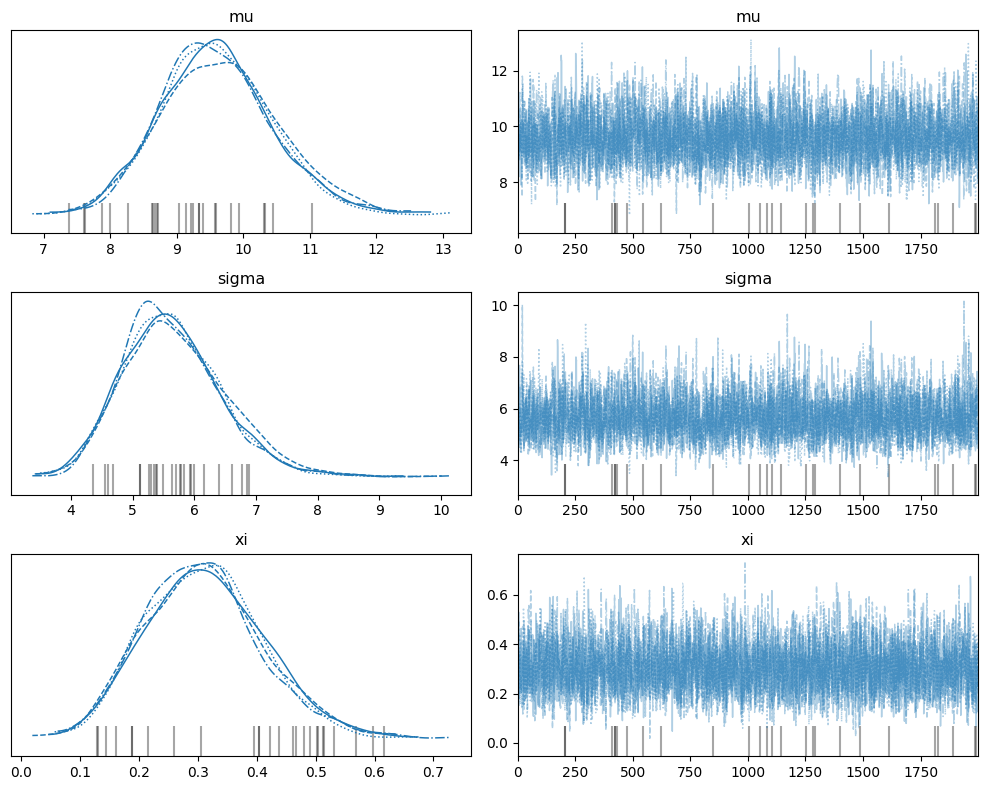

In [4]:
plot_trace(idata_gev);
plt.show()

## 4. Posterior Correlations: Corner (Pair) Plot

The corner plot shows the **joint posterior distributions** of all parameter pairs. Off-diagonal panels are 2D scatter plots of posterior samples; diagonal panels show marginal densities.

For the GEV distribution, a positive correlation between $\sigma$ and $\xi$ is expected — both parameters influence tail heaviness and trade off against each other to fit the data. This correlation:

- Is **normal and expected** — it reflects genuine parameter uncertainty, not a sampling failure.
- Explains why divergences can occur: the narrow, elongated correlation ridge is geometrically challenging for NUTS to traverse.
- Has **practical consequences** for design floods: when $\sigma$ is large and $\xi$ is also large, the upper tail is very heavy — contributing to the wide HDI bands at rare return periods seen in the frequency curve.

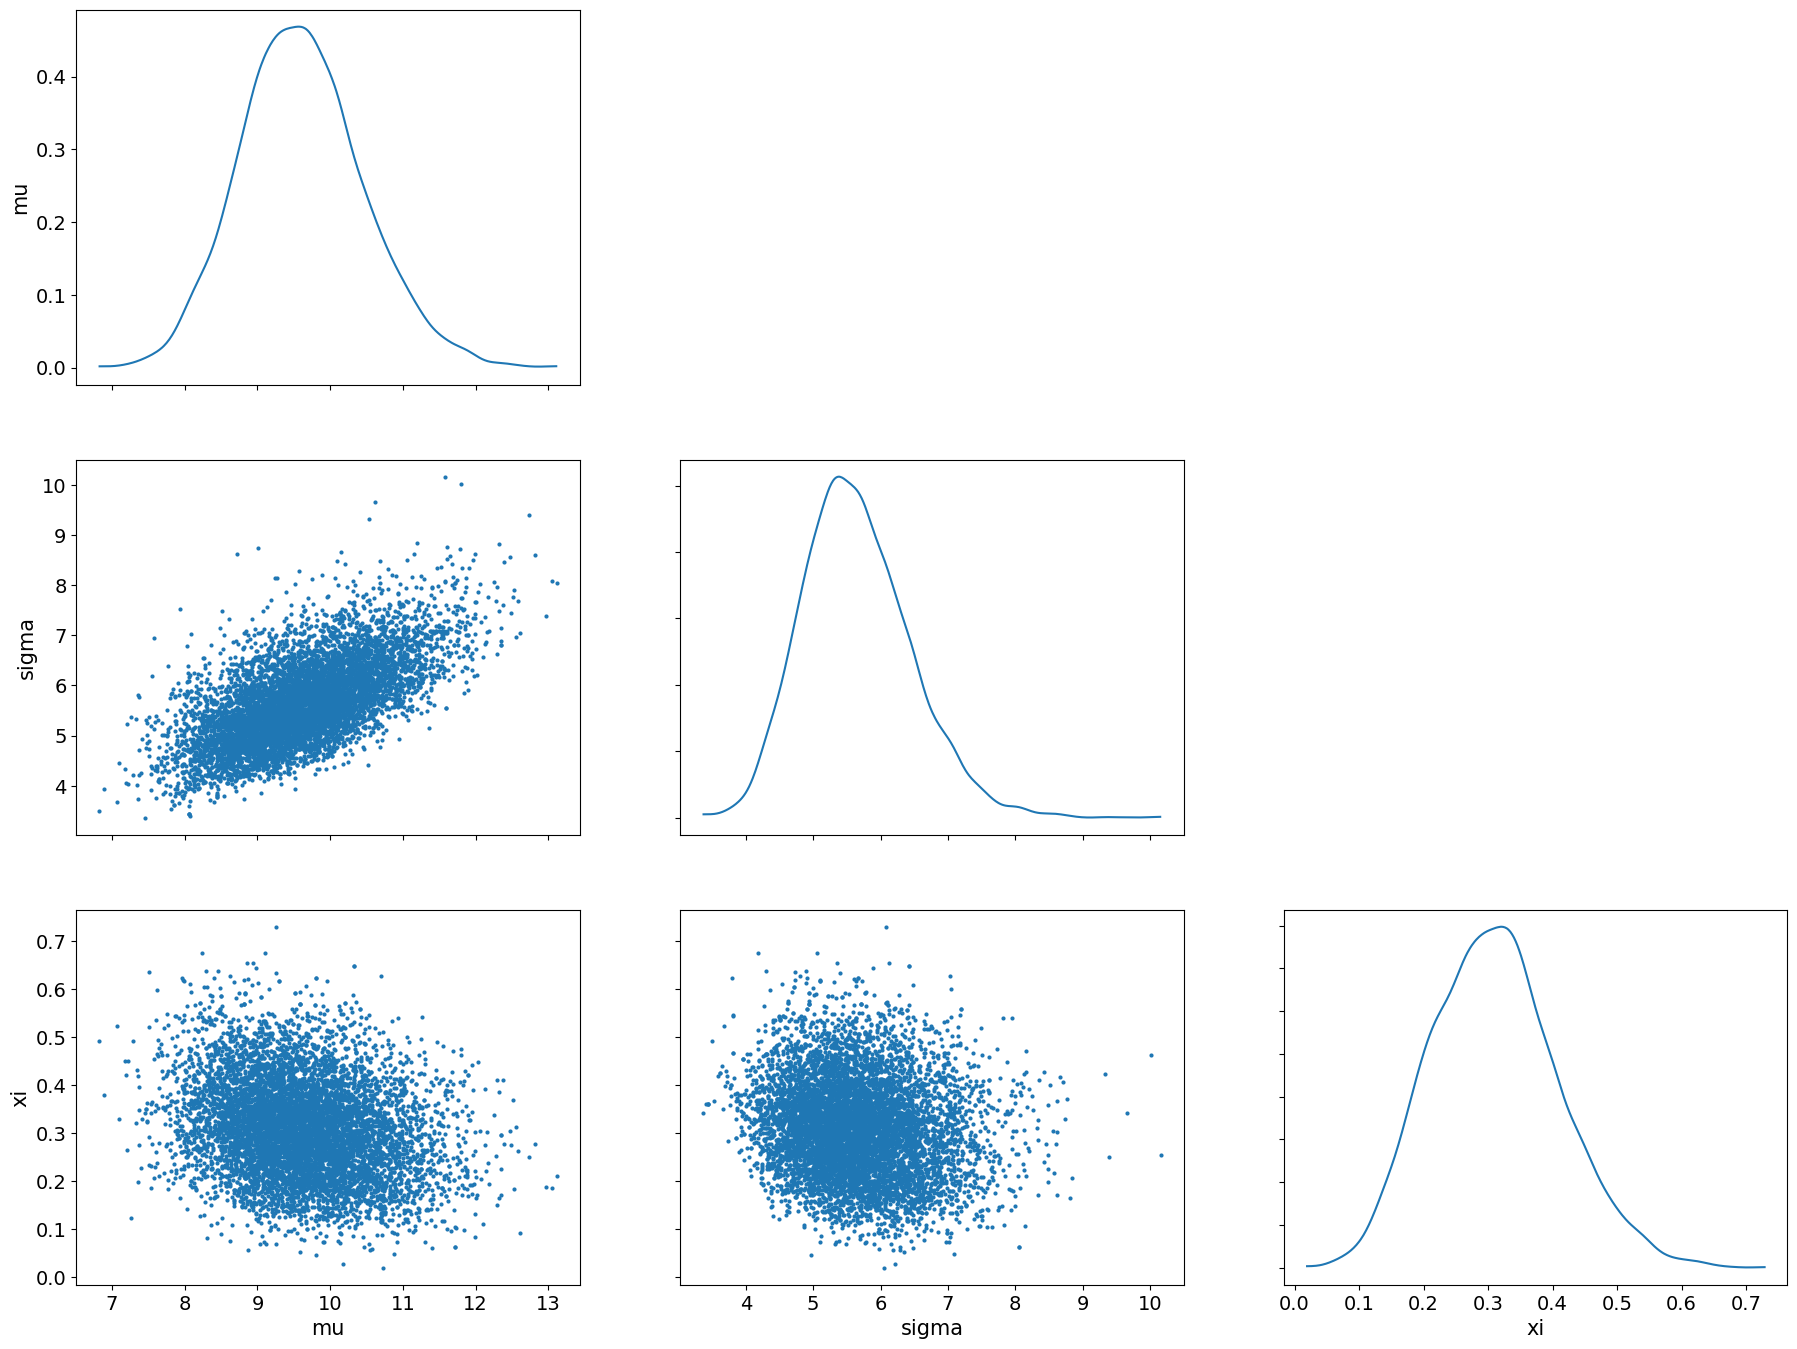

In [5]:
plot_corner(idata_gev);
plt.show()

## 5. Flood Frequency Curve

This plot shows the estimated relationship between **Annual Exceedance Probability (AEP)** and flood magnitude. AEP is the probability that a given flow is exceeded in any single year:

$$\text{AEP\%} = \frac{100}{T}$$

where $T$ is the Average Recurrence Interval in years (e.g., 1% AEP = 100-year ARI).

**Reading the plot:**

| Element | Meaning |
|---|---|
| X axis | AEP (%) on a probability scale — frequent events left, rare events right |
| Y axis | Flow (m³/s) on a log scale |
| Solid line | Posterior **median** return level — the best single estimate |
| Shaded band | **94% Highest Density Interval (HDI)** — the narrowest interval containing 94% of the posterior probability mass |
| Points | Observed AMS data at Cunnane plotting positions |

The **HDI** is a Bayesian credible interval — it directly expresses uncertainty about the true return level, accounting for parameter uncertainty. It is not the same as a frequentist confidence interval. The HDI band widens dramatically at rare return periods (low AEP). This is not a modelling failure — it is an honest statement that extrapolating beyond the record length is inherently uncertain, regardless of the chosen distribution.

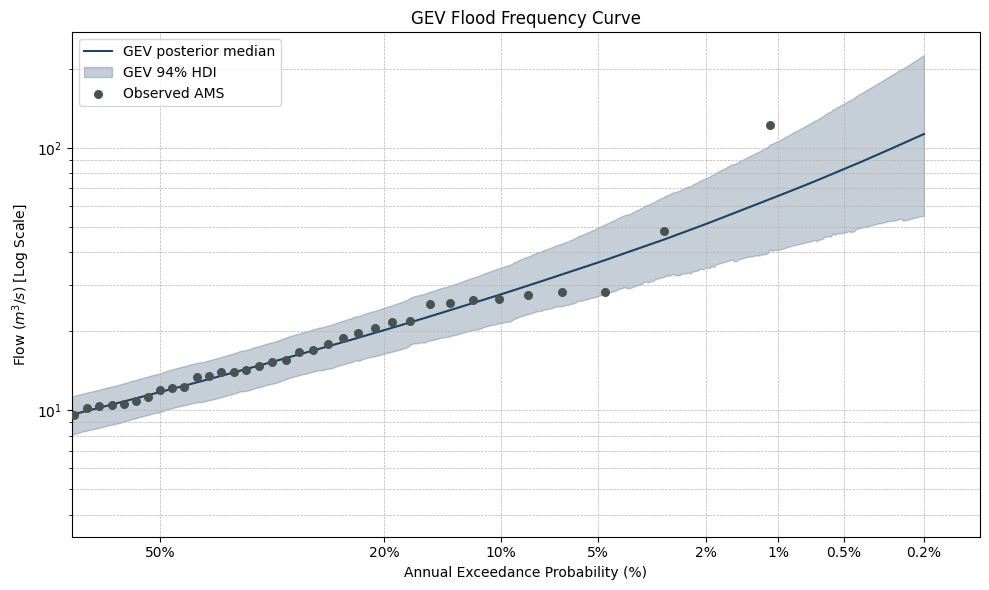

In [6]:
plot_return_levels(idata_gev, flows);
plt.show()

## 6. Posterior Parameter Summary

The table below summarises the marginal posterior for each GEV parameter. Understanding each column is essential for assessing result quality:

| Column | Meaning | Acceptable threshold |
|---|---|---|
| `mean` | Posterior mean | — |
| `sd` | Posterior standard deviation | — |
| `hdi_3%` / `hdi_97%` | Lower/upper bounds of the 94% HDI | — |
| `mcse_mean` | Monte Carlo Standard Error on the mean — sampling noise | Should be < 0.1 × `sd` |
| `ess_bulk` | Effective Sample Size (bulk) — corrects for chain autocorrelation | > 400 |
| `ess_tail` | ESS in the distribution tails — critical for HDI accuracy | > 400 |
| `r_hat` | Gelman–Rubin convergence diagnostic — ratio of between-chain to within-chain variance | < 1.01 (ideally ≈ 1.00) |

**Interpreting the GEV posterior for this dataset:**

- **$\mu \approx 9.6$ m³/s**: The GEV location parameter — approximately the median annual maximum flow.
- **$\sigma \approx 5.6$ m³/s**: The scale — controls the width of the distribution around $\mu$.
- **$\xi \approx 0.31$, 94% HDI (0.13–0.50)**: The shape parameter is **clearly and consistently positive**. The entire HDI lies above zero, confirming a **Fréchet (heavy-tailed)** distribution. There is no physical upper bound on flood magnitude implied by this fit, and the 2021 outlier is a primary driver of this estimate. This has significant consequences for rare event extrapolation — the 0.1% AEP estimate will be substantially larger than the Gumbel ($\xi=0$) case.

An r̂ of 1.00 for all parameters confirms successful convergence despite the divergences noted above.

In [7]:
az.summary(idata_gev, hdi_prob=0.94)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,9.608,0.849,8.059,11.245,0.014,0.010,3840.0,4316.0,1.0
xi,0.310,0.099,0.132,0.497,0.002,0.001,4264.0,4227.0,1.0
sigma,5.643,0.804,4.201,7.130,0.014,0.010,3436.0,4393.0,1.0
